In [1]:
import tifffile
import numpy as np
import rsml
from rsml import hirros
import numpy as np
import matplotlib.pyplot as plt
from gudhi import CubicalComplex
from persim import plot_diagrams


In [5]:
g = rsml.rsml2mtg("/home/loai/Images/DataTest/230629PN010/61_graph_expertized.rsml")
obs_times = hirros.times(g)  # Liste des temps d'observation

# On récupère les propriétés de géométrie et de temps
geometry = g.property('geometry')  # Dictionnaire : { vertex_id: polyline }
time_hours = g.property('time_hours')  # Dictionnaire : { vertex_id: liste_de_temps }
print("geometry", geometry)
print("time_hours", time_hours)

geometry {2: [[391.0, 172.0], [388.0, 193.0], [390.0, 225.0], [391.0, 226.0], [390.0, 241.0], [392.0, 245.0], [391.0, 300.0], [394.0, 308.0], [394.0, 317.0], [390.0, 325.0], [390.0, 346.0], [389.0, 348.0], [388.0, 376.0], [387.0, 392.0], [387.0, 405.0], [385.0, 419.0], [383.0, 433.0], [381.0, 453.0], [378.0, 462.0], [378.0, 473.0], [378.0, 489.0], [377.0, 490.0], [377.0, 499.0], [377.0, 520.0], [376.0, 522.0], [376.0, 543.0], [375.0, 563.0], [374.0, 576.0], [373.0, 582.0], [367.0, 597.0], [365.0, 611.0], [364.0, 635.0], [363.0, 644.0], [360.0, 653.0], [356.0, 667.0], [355.0, 676.0], [355.0, 691.0], [353.0, 704.0], [353.0, 711.0], [349.0, 731.0], [346.0, 753.0], [342.0, 783.0], [340.0, 815.0], [335.0, 832.0], [333.0, 846.0], [333.0, 888.0], [335.0, 919.0], [336.0, 926.0], [335.0, 953.0], [330.0, 967.0], [327.0, 983.0], [326.0, 991.0], [320.0, 1012.0]], 3: [[392.0, 189.0], [394.0, 189.0], [395.0, 190.0], [396.0, 192.0], [398.0, 192.0], [401.0, 193.0], [401.0, 192.0], [403.0, 194.0], [405

In [3]:
#image_stack = tifffile.imread("/home/loai/Images/DataTest/230629PN010/22_registered_stack.tif")

2 0.0


ImportError: cannot import name 'ripser' from 'gudhi' (/home/loai/miniforge3/envs/openalea/lib/python3.10/site-packages/gudhi/__init__.py)

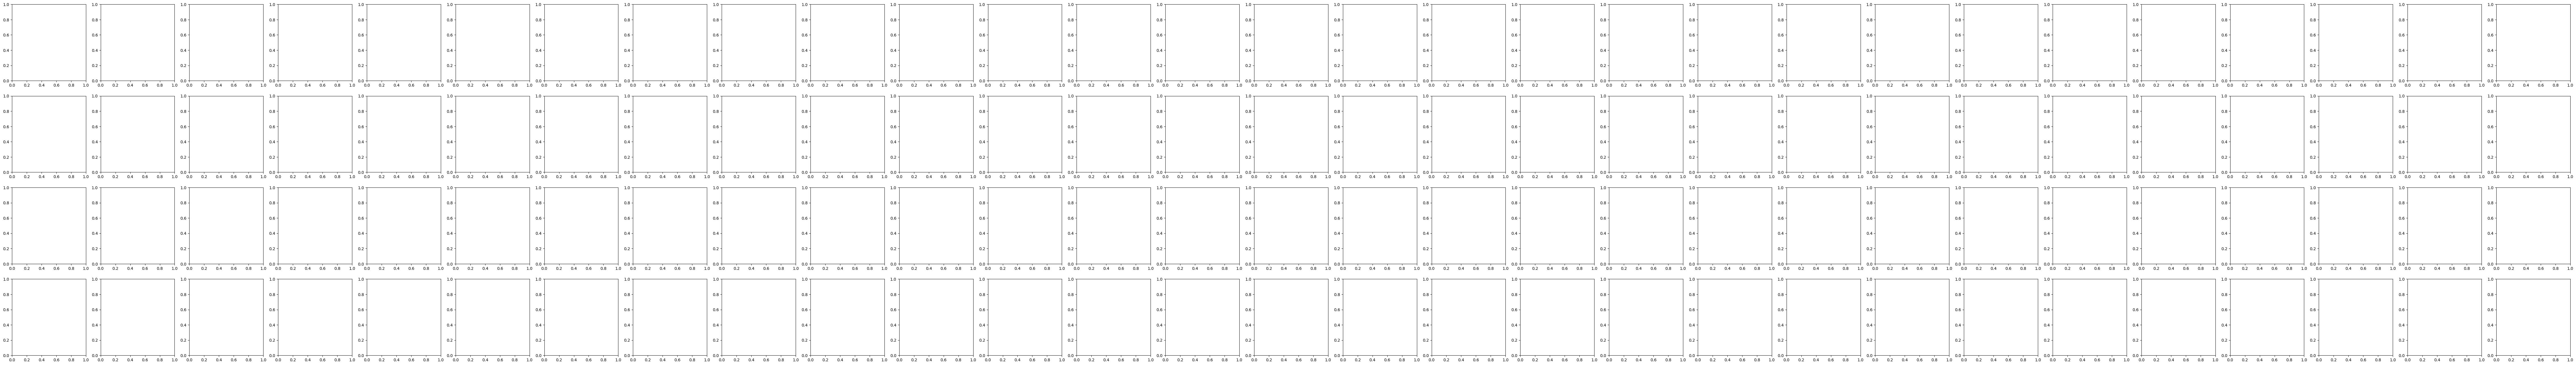

In [ ]:
# Extraire toutes les racines primaires (échelle 2)
primary_roots = g.component_roots_at_scale(g.root, scale=2)

# Définir la grille pour les sous-graphiques
num_roots = len(list(primary for primary in g.component_roots_iter(g.root)))
fig, axs = plt.subplots(num_roots, len(obs_times), figsize=(4*len(obs_times), 4*num_roots))

for i, prim in enumerate(g.component_roots_iter(g.root)):
    for j, obs in enumerate(obs_times):
        primary = prim +1
        print(primary, obs)
        polyline = geometry[primary]
        times = time_hours[primary]

        # On sélectionne les points visibles à l'instant d'observation courant
        visible_points = [pt for pt, t in zip(polyline, time_hours[primary]) if t <= obs_times[j]]
        if len(visible_points) < 2:
            continue

        # Construction d'une matrice de distance pour le diagramme de persistance
        from scipy.spatial.distance import pdist, squareform
        import ripser

        dist_matrix = squareform(pdist(np.array(visible_points)))

        # Diagramme de persistance
        import gudhi as gd
        from gudhi import RipsComplex

        rips_complex = RipsComplex(points=visible_points)
        simplex_tree = rips_complex.create_simplex_tree(max_dimension=2)
        diag = simplex_tree.persistence()

        # Plot persistence diagram
        ax = axs[i, j]
        simplex_tree.plot_persistence_diagram(diag, axes=ax)
        ax.set_title(f'Racine {i+1}, Temps {obs_times[j]}h')

plt.tight_layout()
plt.show()
